# Build human hepatocyte transfwer learning model.

This notebook shows how to build a tranfer learning model to predict human hepatocyte intrinsic clearance. as there is not much hep data on Chembl but lots of microsomal data, we will train on the former and fine tune on the latter.  

In [75]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch

from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

# Print the actual shared libraries being used
print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

# Or more reliably, inspect environment variables
print("\nLD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH", "Not set"))

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda

LD_LIBRARY_PATH: /home/corey/local/openmpi-4.1.4_gcc/lib:/usr/local/cuda-12.9/lib64:/home/corey/software/gnina/build/_deps/libtorch-src/lib:/home/corey/local/openmpi-4.1.4_gcc/lib:/usr/local/cuda-12.9/lib64:/home/corey/local/openmpi-4.1.4_gcc/lib:/usr/local/cuda-12.9/lib64:


## Setup.

In [76]:
readout = 'hep_clint'

In [77]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [108]:
# Load chembl data

cell_type = 'microsome'
species = 'human'

df = pd.read_csv(f'{DATA}/{readout}_{cell_type}_{species}_chembl.csv',index_col=None)
df.head(5)

,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,clint,units,assay_class
0,33031,CHEMBL695026,CHEMBL306457,CL,mL.min-1.kg-1,=,47.7,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,47.7,mL.min-1.kg-1,microsome_human
1,34270,CHEMBL695026,CHEMBL66457,CL,mL.min-1.kg-1,=,4.9,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,4.9,mL.min-1.kg-1,microsome_human
2,34274,CHEMBL695026,CHEMBL304053,CL,mL.min-1.kg-1,=,16.5,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,16.5,mL.min-1.kg-1,microsome_human
3,35507,CHEMBL695026,CHEMBL68366,CL,mL.min-1.kg-1,=,8.0,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,8.0,mL.min-1.kg-1,microsome_human
4,39099,CHEMBL695026,CHEMBL303673,CL,mL.min-1.kg-1,=,6.1,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,6.1,mL.min-1.kg-1,microsome_human


In [109]:
len(df)

15023

In [110]:
# Remove NaN standard_value
df = df[df['clint'].notnull() & np.isfinite(df['clint'])]
len(df)

15023

Is the dataset balanced?

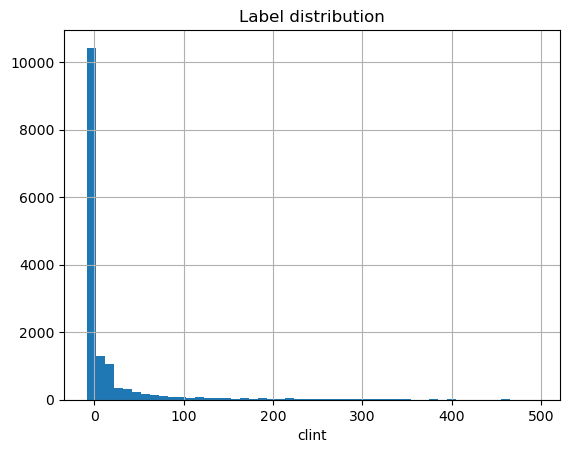

In [111]:
plt.hist(df['clint'], bins=50)
plt.xlabel("clint")
plt.title("Label distribution")
plt.grid(True)
plt.savefig("_images/sample_balance.png", dpi=300)
plt.show()

The dataset is clearly unbalanced need to take a balanced sample.

In [112]:
import numpy as np
import pandas as pd

def hybrid_balanced_sampling_flat_bins(
    df,
    label_col='clint',
    split_threshold=100,
    n_bins_low=15,
    n_bins_high=5,
    target_size=10_000,
    random_state=42
):
    np.random.seed(random_state)
    df = df.copy()

    df_low = df[df[label_col] < split_threshold]
    df_high = df[df[label_col] >= split_threshold]

    # Total bins and samples per bin
    total_bins = n_bins_low + n_bins_high
    samples_per_bin = target_size // total_bins

    # Bin low region
    bins_low = np.linspace(df_low[label_col].min(), split_threshold, n_bins_low + 1)
    df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)

    sampled_low_indices = []
    for bin_id, group in df_low.groupby('bin'):
        if len(group) == 0:
            continue
        n_sample = min(samples_per_bin, len(group))  # no oversampling here
        chosen = np.random.choice(group.index, n_sample, replace=False)
        sampled_low_indices.extend(chosen)

    # Bin high region
    bins_high = np.linspace(split_threshold, df_high[label_col].max(), n_bins_high + 1)
    df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)

    sampled_high_indices = []
    for bin_id, group in df_high.groupby('bin'):
        if len(group) == 0:
            continue
        replace = len(group) < samples_per_bin  # oversample if needed
        chosen = np.random.choice(group.index, samples_per_bin, replace=replace)
        sampled_high_indices.extend(chosen)

    all_indices = list(sampled_low_indices) + list(sampled_high_indices)
    sampled_df = df.loc[all_indices].sample(frac=1, random_state=random_state).reset_index(drop=True)
    sampled_df = sampled_df.drop(columns=['bin'], errors='ignore')

    return sampled_df


In [113]:
sampled_df = hybrid_balanced_sampling_flat_bins(
    df,
    label_col='clint',
    split_threshold=100,
    n_bins_low=15,
    n_bins_high=5,
    target_size=10_000,
    random_state=42
)

/tmp/ipykernel_13837/4222664062.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)
/tmp/ipykernel_13837/4222664062.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)


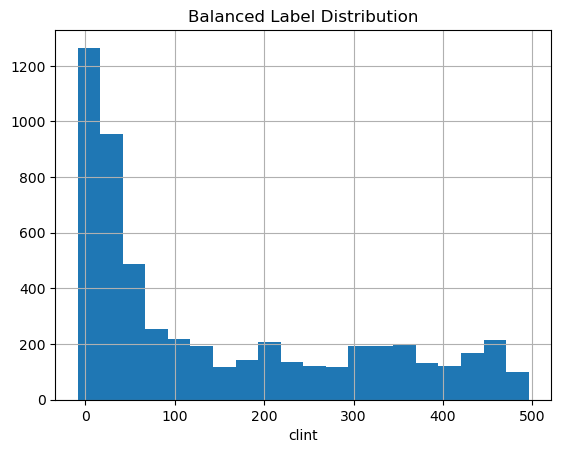

In [114]:
# Is the dataset now balanced?

plt.hist(sampled_df['clint'], bins=20)
plt.xlabel("clint")
plt.title("Balanced Label Distribution")
plt.grid(True)
plt.show()

In [115]:
s = sampled_df['clint']

counts, bins = np.histogram(s, bins=10)

# Print text histogram
for left, count in zip(bins[:-1], counts):
    bar = '█' * int(count / counts.max() * 50) 
    right = left + (bins[1] - bins[0])
    print(f"{left:6.2f} – {right:6.2f}: {bar} {count}")


 -8.60 –  41.86: ██████████████████████████████████████████████████ 2220
 41.86 –  92.32: ████████████████ 740
 92.32 – 142.78: █████████ 412
142.78 – 193.24: █████ 260
193.24 – 243.70: ███████ 341
243.70 – 294.16: █████ 236
294.16 – 344.62: ████████ 385
344.62 – 395.08: ███████ 329
395.08 – 445.54: ██████ 288
445.54 – 496.00: ███████ 315


In [ ]:
# # Log transform Clint:

# df = df[pd.to_numeric(df['clint'], errors='coerce').notna()]
# df = df[df['clint'] > 0]
# df['log_clint'] = np.log10(df['clint'] + 1e-3)

In [ ]:
# plt.hist(df['log_clint'], bins=40)
# plt.xlabel("log10(Clint)")
# plt.ylabel("Count")
# plt.title("Distribution after preprocessing")


In [ ]:
# print(sampled_df['log_clint'].describe())
# print(np.isnan(sampled_df['log_clint']).sum())

In [116]:
smiles_list = sampled_df['smiles'].tolist()
clint_values = sampled_df['clint'].tolist()

Pytorch geometric fix

In [117]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [118]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

## Featurisation step.

In [119]:
# We can get reasonable results (R^2 ~ 0.5) with simple atomic features.
# But as we are trying to predict a more complex phenomena, we can benefit from RdKit 
# descriptors to encode hybridisation, partial charges, etc.
# Prediction should improve from here.

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount
]

# Precompute electronegativity and polarizability dictionaries
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

polarizability_dict = {
    1: 0.666, 6: 1.76, 7: 1.1, 8: 0.802, 9: 0.557, 15: 3.63,
    16: 3.6, 17: 2.18,
}

metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def safe_value(x):
    if x is None or np.isnan(x) or np.isinf(x):
        return 0.0
    return x

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (scaled/formatted)
    features += [
        atom.GetDegree(),               # number of bonded neighbors
        atom.GetFormalCharge() / 3.0,  # scaled formal charge (-3 to +3)
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
    ]

    # Ring size one-hot for common ring sizes
    ring_sizes = [3, 4, 5, 6, 7, 8]
    for size in ring_sizes:
        features.append(int(atom.IsInRingSize(size)))

    atomic_num = atom.GetAtomicNum()

    # Physical properties normalized
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # atomic weight normalized ~0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # van der Waals radius normalized
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # electronegativity normalized
        polarizability_dict.get(atomic_num, 1.0) / 5.0,       # polarizability normalized
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # valence electrons normalized
        1.0 if atomic_num in metals else 0.0                  # metal indicator
    ]

    # Partial charge (Gasteiger)
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
        except:
            charge = 0.0
        features.append(charge)
    else:
        features.append(0.0)

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        # Bond stereo features
        int(bond.GetStereo() == Chem.rdchem.BondStereo.STEREOZ),
        int(bond.GetStereo() == Chem.rdchem.BondStereo.STEREOE),
        int(bond.GetStereo() == Chem.rdchem.BondStereo.STEREOANY),
    ]
    return np.array(features, dtype=np.float32)


In [120]:
# Add metabolic SMARTS as global features.

metabolic_smarts = {
    'aromatic_amine': '[a][NH2,NH,N]',
    'phenol': 'c[OH]',
    'ester': 'C(=O)O',
    'ether': 'C-O-C',
    'thioether': 'C-S-C',
    'nitro': '[N+](=O)[O-]',
    'heteroaromatic': '[a;!#6]',  # aromatic heteroatoms
}

compiled_smarts = {k: Chem.MolFromSmarts(v) for k, v in metabolic_smarts.items()}

def get_metabolic_flags(mol):
    flags = []
    for name, pattern in compiled_smarts.items():
        flags.append(int(mol.HasSubstructMatch(pattern)))
    return flags


In [121]:
def mol_to_graph(smiles: str, label: float = None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            val = safe_value(val)
        except:
            val = 0.0
        global_features.append(val)

    # Add metabolic SMARTS flags to global features
    global_features += get_metabolic_flags(mol)

    global_features = torch.tensor(global_features, dtype=torch.float32)

    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    return data


Data loader code.

In [122]:
# We have to tell the DataLoader which features to expect (with metabolic features).

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback zeros for original descriptors + metabolic flags
        total_length = len(descriptor_functions) + len(compiled_smarts)
        return torch.zeros(total_length, dtype=torch.float)

    feats = [safe_value(fn(mol)) for fn in descriptor_functions]
    feats += get_metabolic_flags(mol)  # metabolic flags are 0/1 integers
    
    return torch.tensor(feats, dtype=torch.float)

In [123]:
def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [124]:
# Create data list
data_list = []
for smi, lbl in zip(smiles_list, clint_values):
    data = mol_to_graph(smi, label=lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

## The Regression model definition.

In [ ]:
# Trying a lighter model than an attention-based model

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
from torch_geometric.nn import GINConv, GlobalAttention

class GINRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, global_feat_dim=0, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.global_feat_dim = global_feat_dim
        self.dropout = dropout

        # Define GIN layers
        nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        nn3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.conv3 = GINConv(nn3)

        # BatchNorm layers
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Attention pooling (learns importance of atoms)
        self.att_pool = GlobalAttention(
            gate_nn=nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )
        )

        # Fully connected readout head
        self.lin = nn.Sequential(
            nn.Linear(hidden_dim + global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GIN block 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GIN block 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GIN block 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # Attention pooling
        x = self.att_pool(x, batch)

        # Concatenate global descriptors
        if hasattr(data, "global_features"):
            global_feat = data.global_features.to(x.device)
            x = torch.cat([x, global_feat], dim=1)

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [126]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [127]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [128]:
def train_with_early_stopping(params):
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0),
        dropout=0.2
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 15
    counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(200):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load('best_model.pth'))

    # Plot loss curves
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.savefig(f"_images/grid_search_lr_{params['lr']}_hidden_dim_{params['hidden_dim']}.png", dpi=300)

    return model

With hyperparameter tuning.


Training with lr=0.0001, hidden_dim=64


/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


Epoch 1 | Train: 40436.0648 | Val: 35508.8984
Epoch 2 | Train: 30308.3149 | Val: 25800.6169
Epoch 3 | Train: 25105.4199 | Val: 23944.6460
Epoch 4 | Train: 24147.2552 | Val: 23596.6885
Epoch 5 | Train: 24013.8499 | Val: 23573.1130
Epoch 6 | Train: 24270.8955 | Val: 22808.2506
Epoch 7 | Train: 23491.5517 | Val: 23482.7977
Epoch 8 | Train: 22949.5727 | Val: 21865.9293
Epoch 9 | Train: 23050.5975 | Val: 22121.6329
Epoch 10 | Train: 22434.3794 | Val: 21150.6282
Epoch 11 | Train: 22013.5124 | Val: 21670.0940
Epoch 12 | Train: 22116.4161 | Val: 21447.2073
Epoch 13 | Train: 22314.3550 | Val: 20882.5865
Epoch 14 | Train: 21282.3328 | Val: 20384.5244
Epoch 15 | Train: 21383.6381 | Val: 19437.9521
Epoch 16 | Train: 21524.9451 | Val: 19800.6543
Epoch 17 | Train: 20906.0738 | Val: 20729.1318
Epoch 18 | Train: 20624.2528 | Val: 20715.3528
Epoch 19 | Train: 20670.6268 | Val: 18939.9829
Epoch 20 | Train: 20631.6442 | Val: 19243.2600
Epoch 21 | Train: 20403.7759 | Val: 19221.8376
Epoch 22 | Train: 2017

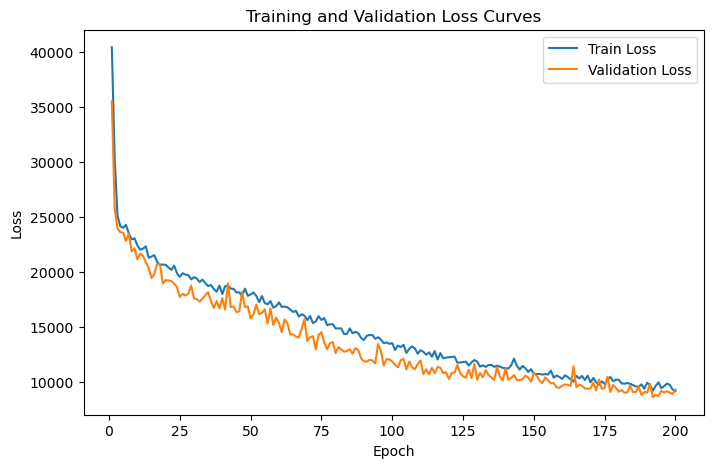

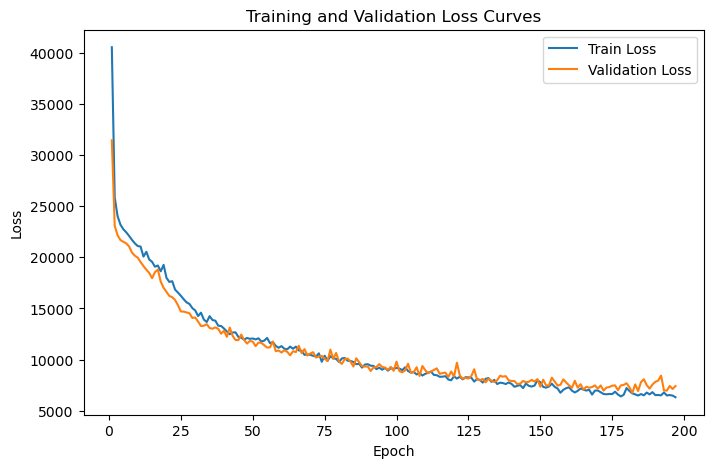

In [129]:
input_dim = data_list[0].x.shape[1]
global_feat_dim = 16 # number of global features + metabolic groups

param_grid = {
    # 'lr': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],  # Learning rates spanning two orders of magnitude
    # 'hidden_dim': [32, 64, 128, 256],      # Network width
    'lr': [1e-4],  # Learning rates spanning two orders of magnitude
    'hidden_dim': [64, 128],      # Network width
    # 'num_layers': [2, 3, 5],               # GIN depth - common sweet spots
    # 'dropout': [0.0, 0.2, 0.5],            # Regularisation via dropout
    # 'batch_size': [32, 64, 128],           # Mini-batch sizes
    # 'weight_decay': [0.0, 1e-5, 1e-4],     # L2 regularisation on weights
    # 'readout': ['sum', 'mean', 'max'],     # Different aggregation schemes (depends on your GIN implementation)
    # 'activation': ['relu', 'leakyrelu'],   # Activation function choice
}

best_model = None
best_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"\nTraining with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss())

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

## Evaluation


Best params: {'lr': 0.0001, 'hidden_dim': 128, 'input_dim': 44, 'global_feat_dim': 16}

RMSE: 81.9572
MAE: 56.4748
R²: 0.7168


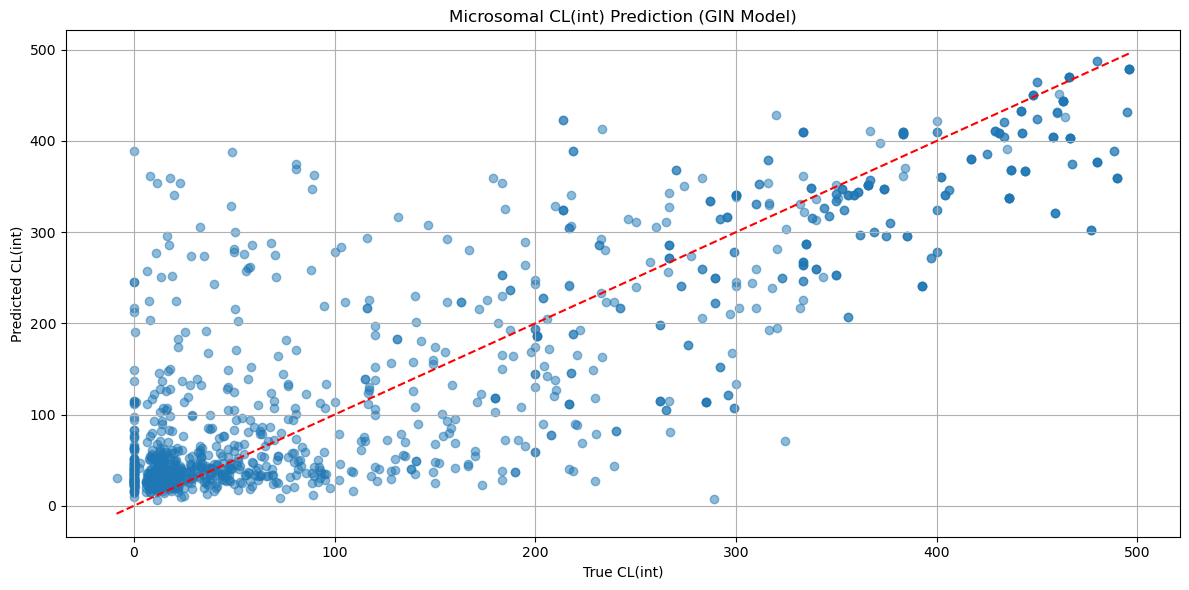

In [130]:
print(f"\nBest params: {best_params}")

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = best_model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True CL(int)")
plt.ylabel("Predicted CL(int)")
plt.title("Microsomal CL(int) Prediction (GIN Model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("_images/true_vs_predicted_clint.png", dpi=300)
plt.show()

## Transfer learning.

Okay so we have a trained GIN model on microsomal clint. Let's set up some transfer learning on the hep data. 

In [180]:
# Load chembl data

cell_type = 'hepatocyte'
species = 'human'

df_hep = pd.read_csv(f'{DATA}/{readout}_{cell_type}_{species}_chembl.csv',index_col=None)

In [249]:
sampled_hep_df = hybrid_balanced_sampling_flat_bins(
    df_hep,
    label_col='clint',
    split_threshold=100,
    n_bins_low=15,
    n_bins_high=5,
    target_size=10000,
    random_state=42
)

/tmp/ipykernel_13837/4222664062.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low['bin'] = pd.cut(df_low[label_col], bins=bins_low, include_lowest=True, labels=False)
/tmp/ipykernel_13837/4222664062.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high['bin'] = pd.cut(df_high[label_col], bins=bins_high, include_lowest=True, labels=False)


In [250]:
s = sampled_hep_df['clint']

counts, bins = np.histogram(s, bins=10)

# Print text histogram
for left, count in zip(bins[:-1], counts):
    bar = '█' * int(count / counts.max() * 50) 
    right = left + (bins[1] - bins[0])
    print(f"{left:6.2f} – {right:6.2f}: {bar} {count}")


  0.00 –  47.10: ██████████████████████████████████████████████████ 818
 47.10 –  94.20: ███ 64
 94.20 – 141.30: ███████████████████████ 390
141.30 – 188.40: ███████████████████ 318
188.40 – 235.50: ████████████████ 269
235.50 – 282.60: █████████████████████ 352
282.60 – 329.70: ██████████ 174
329.70 – 376.80: ███████████████████████████ 446
376.80 – 423.90: █████████████████ 294
423.90 – 471.00: ███████████████ 260


In [251]:
# #log-transform CLint again:

# sampled_hep_df["log_clint"] = np.log10(sampled_hep_df["clint"] + 1e-3)

In [252]:
# Convert SMILES + labels → PyG Data objects and attach SMILES as attribute
hep_data_list = []
for smi, label in zip(sampled_hep_df.smiles, sampled_hep_df.clint):
    d = mol_to_graph(smi, label)
    if d is not None:
        d.smiles = smi  # attach SMILES string for later use
        hep_data_list.append(d)


In [253]:
from sklearn.model_selection import train_test_split

hep_train, hep_val = train_test_split(hep_data_list, test_size=0.2, random_state=42)
hep_train_loader = DataLoader(hep_train, batch_size=16, shuffle=True, collate_fn=custom_collate)
hep_val_loader   = DataLoader(hep_val, batch_size=16, shuffle=False, collate_fn=custom_collate)

In [254]:
pretrained_model = GINRegressor(
    input_dim=input_dim,
    hidden_dim=best_params["hidden_dim"],
    global_feat_dim=best_params["global_feat_dim"],
    dropout=0.2
).to(device)

pretrained_model.load_state_dict(torch.load("best_model.pth"))

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


<All keys matched successfully>

In [255]:
# for name, param in pretrained_model.named_parameters():
#     if "lin" not in name:   # freeze everything except final head
#         param.requires_grad = False


# Due to poor performance, we unfreeze the last GIN block + the head
for name, param in pretrained_model.named_parameters():
    if "conv3" in name or "bn3" in name or "lin" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


In [257]:
# verify which layers are frozen.

for name, param in pretrained_model.named_parameters():
    print(name, param.requires_grad)


conv1.nn.0.weight False
conv1.nn.0.bias False
conv1.nn.2.weight False
conv1.nn.2.bias False
conv2.nn.0.weight False
conv2.nn.0.bias False
conv2.nn.2.weight False
conv2.nn.2.bias False
conv3.nn.0.weight True
conv3.nn.0.bias True
conv3.nn.2.weight True
conv3.nn.2.bias True
bn1.weight False
bn1.bias False
bn2.weight False
bn2.bias False
bn3.weight True
bn3.bias True
att_pool.gate_nn.0.weight False
att_pool.gate_nn.0.bias False
att_pool.gate_nn.2.weight False
att_pool.gate_nn.2.bias False
lin.0.weight True
lin.0.bias True
lin.3.weight True
lin.3.bias True
lin.6.weight True
lin.6.bias True


In [258]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, pretrained_model.parameters()), lr=1e-4)
loss_fn = torch.nn.MSELoss()

best_val_loss = float("inf")
patience, counter = 15, 0

for epoch in range(100):
    train_loss = train_epoch(pretrained_model, hep_train_loader, optimizer, loss_fn)
    val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pretrained_model.state_dict(), "finetuned_hep_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1 | Train: 25291.7174 | Val: 15582.6189
Epoch 2 | Train: 17337.7735 | Val: 13186.2227
Epoch 3 | Train: 15175.2496 | Val: 11213.8429
Epoch 4 | Train: 13236.0215 | Val: 9698.7840
Epoch 5 | Train: 11773.3739 | Val: 9666.3231
Epoch 6 | Train: 11037.0838 | Val: 9049.3876
Epoch 7 | Train: 10078.7528 | Val: 8709.4071
Epoch 8 | Train: 9532.6163 | Val: 7622.7475
Epoch 9 | Train: 9616.1399 | Val: 8041.2608
Epoch 10 | Train: 9186.6282 | Val: 6967.3056
Epoch 11 | Train: 8669.8106 | Val: 7254.6458
Epoch 12 | Train: 8145.3588 | Val: 6529.4271
Epoch 13 | Train: 7991.3675 | Val: 6633.5146
Epoch 14 | Train: 7810.1614 | Val: 5801.2248
Epoch 15 | Train: 7729.7542 | Val: 5453.8487
Epoch 16 | Train: 7227.4039 | Val: 4980.9991
Epoch 17 | Train: 7035.9107 | Val: 5614.6108
Epoch 18 | Train: 6875.0198 | Val: 5822.3909
Epoch 19 | Train: 6782.0533 | Val: 4694.2626
Epoch 20 | Train: 6255.1807 | Val: 4135.9044
Epoch 21 | Train: 6303.1885 | Val: 4751.5965
Epoch 22 | Train: 6126.6103 | Val: 4608.3912
Epoch 23 

In [259]:
pretrained_model.load_state_dict(torch.load("finetuned_hep_model.pth"))
val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

preds = preds.numpy()
labels = labels.numpy()

rmse = np.sqrt(np.mean((preds - labels)**2))
mae = np.mean(np.abs(preds - labels))
r2 = 1 - np.sum((preds - labels)**2) / np.sum((labels - np.mean(labels))**2)

print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


RMSE: 47.5916 | MAE: 27.5201 | R²: 0.8955


That's very high and we should be very suspicious. Let's check SMILES and scaffold similarity in the dataset.

In [261]:
smiles = [d for d in sampled_hep_df]
dup_count = pd.Series(smiles).duplicated().sum()
print(f"{dup_count} duplicate SMILES found.")


0 duplicate SMILES found.


In [262]:
from rdkit.Chem import AllChem, DataStructs

def fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)

train_fps = [fp(d.smiles) for d in hep_train]
val_fps = [fp(d.smiles) for d in hep_val]

sims = []
for v_fp in val_fps:
    sims.append(max(DataStructs.BulkTanimotoSimilarity(v_fp, train_fps)))
print(f"Mean max similarity (val→train): {sum(sims)/len(sims):.3f}")


[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerator
[15:55:36] DEPRECATION WARNING: please use MorganGenerat

Mean max similarity (val→train): 0.936


[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerator
[15:55:37] DEPRECATION WARNING: please use MorganGenerat

Yup, `Mean max similarity (val→train): 0.936` is a bad sign. Let's re-do the train/val split by scaffold and see where we are. 

In [263]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import random

def scaffold_split(dataset, frac_train=0.8, frac_val=0.2, seed=42):
    # Group compounds by scaffold
    scaffolds = {}
    for data in dataset:
        mol = Chem.MolFromSmiles(data.smiles)
        if mol is None:
            continue
        scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        scaffolds.setdefault(scaf, []).append(data)

    # Shuffle scaffold groups
    random.seed(seed)
    scaffold_sets = list(scaffolds.values())
    random.shuffle(scaffold_sets)

    # Assign groups to splits
    n_total = len(dataset)
    n_train = int(frac_train * n_total)
    train, val = [], []
    for group in scaffold_sets:
        if len(train) + len(group) <= n_train:
            train.extend(group)
        else:
            val.extend(group)
    return train, val


In [264]:
hep_train, hep_val = scaffold_split(hep_data_list)

In [265]:
hep_train_loader = DataLoader(hep_train, batch_size=16, shuffle=True, collate_fn=custom_collate)
hep_val_loader   = DataLoader(hep_val, batch_size=16, shuffle=False, collate_fn=custom_collate)

In [266]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, pretrained_model.parameters()), lr=1e-4)
loss_fn = torch.nn.MSELoss()

best_val_loss = float("inf")
patience, counter = 15, 0

for epoch in range(100):
    train_loss = train_epoch(pretrained_model, hep_train_loader, optimizer, loss_fn)
    val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pretrained_model.state_dict(), "finetuned_hep_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1 | Train: 3429.6320 | Val: 2183.5703
Epoch 2 | Train: 3278.2894 | Val: 2732.6155
Epoch 3 | Train: 3217.0875 | Val: 3351.9499
Epoch 4 | Train: 3220.8484 | Val: 2884.5473
Epoch 5 | Train: 3171.2035 | Val: 3041.4381
Epoch 6 | Train: 3070.2580 | Val: 3158.8941
Epoch 7 | Train: 3020.2194 | Val: 3176.7913
Epoch 8 | Train: 3050.2711 | Val: 3386.7210
Epoch 9 | Train: 2886.5906 | Val: 3833.3845
Epoch 10 | Train: 3049.7756 | Val: 3823.7922
Epoch 11 | Train: 2932.8444 | Val: 3619.5894
Epoch 12 | Train: 2978.5756 | Val: 4129.1517
Epoch 13 | Train: 2932.2829 | Val: 3510.2071
Epoch 14 | Train: 2682.9028 | Val: 3601.8411
Epoch 15 | Train: 2872.8547 | Val: 4009.4143
Epoch 16 | Train: 2717.3861 | Val: 4208.7816
Early stopping triggered.


In [267]:
pretrained_model.load_state_dict(torch.load("finetuned_hep_model.pth"))
val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

preds = preds.numpy()
labels = labels.numpy()

rmse = np.sqrt(np.mean((preds - labels)**2))
mae = np.mean(np.abs(preds - labels))
r2 = 1 - np.sum((preds - labels)**2) / np.sum((labels - np.mean(labels))**2)

print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


RMSE: 47.0344 | MAE: 28.2429 | R²: 0.9188


In [268]:
from rdkit.Chem import AllChem, DataStructs

def fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)

train_fps = [fp(d.smiles) for d in hep_train]
val_fps = [fp(d.smiles) for d in hep_val]

sims = []
for v_fp in val_fps:
    sims.append(max(DataStructs.BulkTanimotoSimilarity(v_fp, train_fps)))
print(f"Mean max similarity (val→train): {sum(sims)/len(sims):.3f}")


[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerat

Mean max similarity (val→train): 0.684


[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerat

Well, the performance is still high but now the scaffold similarity is low (`Mean max similarity (val→train): 0.684`). Let's try with some random seeds to see if the performance holds.

In [269]:
for seed in [42, 123, 999]:
    hep_train, hep_val = scaffold_split(hep_data_list, seed=seed)

    hep_train_loader = DataLoader(hep_train, batch_size=16, shuffle=True, collate_fn=custom_collate)
    hep_val_loader   = DataLoader(hep_val, batch_size=16, shuffle=False, collate_fn=custom_collate)

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, pretrained_model.parameters()), lr=1e-4)
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float("inf")
    patience, counter = 15, 0

    for epoch in range(100):
        train_loss = train_epoch(pretrained_model, hep_train_loader, optimizer, loss_fn)
        val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(pretrained_model.state_dict(), "finetuned_hep_model.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    pretrained_model.load_state_dict(torch.load("finetuned_hep_model.pth"))
    val_loss, preds, labels = eval_epoch(pretrained_model, hep_val_loader, loss_fn)

    preds = preds.numpy()
    labels = labels.numpy()

    rmse = np.sqrt(np.mean((preds - labels)**2))
    mae = np.mean(np.abs(preds - labels))
    r2 = 1 - np.sum((preds - labels)**2) / np.sum((labels - np.mean(labels))**2)

    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


Epoch 1 | Train: 3402.0890 | Val: 2725.3138
Epoch 2 | Train: 3250.3040 | Val: 2773.9049
Epoch 3 | Train: 3155.4491 | Val: 3491.9723
Epoch 4 | Train: 3180.1295 | Val: 3149.5193
Epoch 5 | Train: 3007.4500 | Val: 3338.0363
Epoch 6 | Train: 3255.2389 | Val: 3177.2372
Epoch 7 | Train: 2896.7966 | Val: 3359.3620
Epoch 8 | Train: 2961.6293 | Val: 3533.3648
Epoch 9 | Train: 2862.6729 | Val: 4297.8201
Epoch 10 | Train: 2915.0158 | Val: 3825.8074
Epoch 11 | Train: 2883.8556 | Val: 3942.2139
Epoch 12 | Train: 2721.3520 | Val: 3803.6131
Epoch 13 | Train: 2890.8290 | Val: 3555.4459
Epoch 14 | Train: 2685.8090 | Val: 3863.0119
Epoch 15 | Train: 2829.5698 | Val: 4381.4863
Epoch 16 | Train: 2789.0501 | Val: 4272.2009
Early stopping triggered.
RMSE: 52.3262 | MAE: 31.6308 | R²: 0.8995
Epoch 1 | Train: 3273.2970 | Val: 1971.8571
Epoch 2 | Train: 3091.3561 | Val: 3424.9019
Epoch 3 | Train: 3045.4563 | Val: 2641.0641
Epoch 4 | Train: 2949.0653 | Val: 2718.8831
Epoch 5 | Train: 2931.4760 | Val: 3067.0157
E

It's plausible but scepticism is prudent. Time for some CV.

### Cross-validation run.

In [270]:
def train_fold(train_idx, val_idx, params, pretrained_path, fold, device):
    train_subset = [data_list[i] for i in train_idx]
    val_subset = [data_list[i] for i in val_idx]

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=custom_collate)

    def train_epoch_fold(model, loader, optimizer, loss_fn):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def eval_epoch_fold(model, loader, loss_fn):
        model.eval()
        total_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.to(device).float())
                total_loss += loss.item()
                all_preds.append(out.cpu())
                all_labels.append(batch.y.cpu())
        return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

    # --- Load pretrained microsomal model ---
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0),
        dropout=0.2
    ).to(device)

    model.load_state_dict(torch.load(pretrained_path))

    # --- Optional: unfreeze last GIN block + head only ---
    for name, param in model.named_parameters():
        if "conv3" in name or "bn3" in name or "lin" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=params['lr']
    )
    loss_fn = torch.nn.MSELoss()

    # --- Training loop ---
    best_val_loss = float('inf')
    patience, counter = 10, 0
    best_path = f'best_model_fold_{fold}.pth'

    for epoch in range(100):
        train_loss = train_epoch_fold(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch_fold(model, val_loader, loss_fn)
        print(f"Fold {fold+1} | Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(best_path))
    return model, best_val_loss


In [272]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_dim = data_list[0].x.shape[1]
global_feat_dim = 16

param_grid = {
    'lr': 1e-4,  # smaller LR for fine-tuning
    'hidden_dim': 128,
    'input_dim': input_dim,
    'global_feat_dim': global_feat_dim
}

pretrained_path = "finetuned_hep_model.pth"  # microsomal pretrained model
val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(data_list)):
    print(f"\n========== Fold {fold+1} ==========")
    model, val_loss = train_fold(train_idx, val_idx, param_grid, pretrained_path, fold, device)
    val_losses.append(val_loss)

print(f"\nAverage validation loss across folds: {sum(val_losses)/len(val_losses):.4f}")



========== Fold 1 ==========
Fold 1 | Epoch 1 | Train: 17868.1276 | Val: 12211.7300
Fold 1 | Epoch 2 | Train: 12441.3069 | Val: 10478.9596
Fold 1 | Epoch 3 | Train: 10714.8831 | Val: 9744.8072
Fold 1 | Epoch 4 | Train: 9724.8143 | Val: 9294.1230
Fold 1 | Epoch 5 | Train: 9320.0331 | Val: 8876.4421
Fold 1 | Epoch 6 | Train: 8603.8224 | Val: 8319.1567
Fold 1 | Epoch 7 | Train: 8300.3675 | Val: 8544.9821
Fold 1 | Epoch 8 | Train: 8338.9027 | Val: 7910.7205
Fold 1 | Epoch 9 | Train: 7868.0252 | Val: 8232.6184
Fold 1 | Epoch 10 | Train: 7805.4786 | Val: 7903.4042
Fold 1 | Epoch 11 | Train: 7656.8187 | Val: 7800.4335
Fold 1 | Epoch 12 | Train: 7408.6574 | Val: 7577.8875
Fold 1 | Epoch 13 | Train: 7132.7895 | Val: 7720.5158
Fold 1 | Epoch 14 | Train: 7289.0534 | Val: 7668.0710
Fold 1 | Epoch 15 | Train: 7174.1258 | Val: 7366.3502
Fold 1 | Epoch 16 | Train: 7138.1736 | Val: 7583.6151
Fold 1 | Epoch 17 | Train: 6890.4729 | Val: 7181.7337
Fold 1 | Epoch 18 | Train: 7095.0711 | Val: 7242.1391
Fo

Final check; before saving, let's look at any significant differences in L2 weight norms between each model generated in CV.

In [277]:
# Setup
FOLD_PATHS = [f'best_model_fold_{i}.pth' for i in range(5)]
DEVICE = 'cuda'  # or 'cuda' if available
sns.set(style='whitegrid')

# Need to redefine the model here
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn import Sequential, Linear, ReLU

class GINRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, global_feat_dim=0, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.global_feat_dim = global_feat_dim
        self.dropout = dropout

        # Define GIN layers
        nn1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        nn2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        nn3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.conv3 = GINConv(nn3)

        # BatchNorm layers
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Attention pooling (learns importance of atoms)
        self.att_pool = GlobalAttention(
            gate_nn=nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )
        )

        # Fully connected readout head
        self.lin = nn.Sequential(
            nn.Linear(hidden_dim + global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # GIN block 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GIN block 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GIN block 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # Attention pooling
        x = self.att_pool(x, batch)

        # Concatenate global descriptors
        if hasattr(data, "global_features"):
            global_feat = data.global_features.to(x.device)
            x = torch.cat([x, global_feat], dim=1)

        return self.lin(x).squeeze(1)

# Use the best parameters from the grid search in training
# Best params: {'lr': 0.0001, 'hidden_dim': 128, 'input_dim': 44, 'global_feat_dim': 16}
params = {
    'input_dim': 44,         # Replace with your actual input_dim
    'hidden_dim': 128,        # Replace with your actual hidden_dim
    'global_feat_dim': 16     # Replace if you used global features
}

# Load each model from disk
models = []
for fold_path in FOLD_PATHS:
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(DEVICE)
    state_dict = torch.load(fold_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    models.append(model)

# Extract all weights from each model
def get_all_weights(model: torch.nn.Module) -> np.ndarray:
    weights = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights.append(param.detach().cpu().numpy().flatten())
    return np.concatenate(weights)

def get_model():
    return GINRegressor(
        input_dim=44,
        hidden_dim=128,
        global_feat_dim=16  # Optional
    )
    return model

# Load models and compute L2 norms per layer
def get_weight_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            norms[name] = param.data.norm(2).item()
    return norms

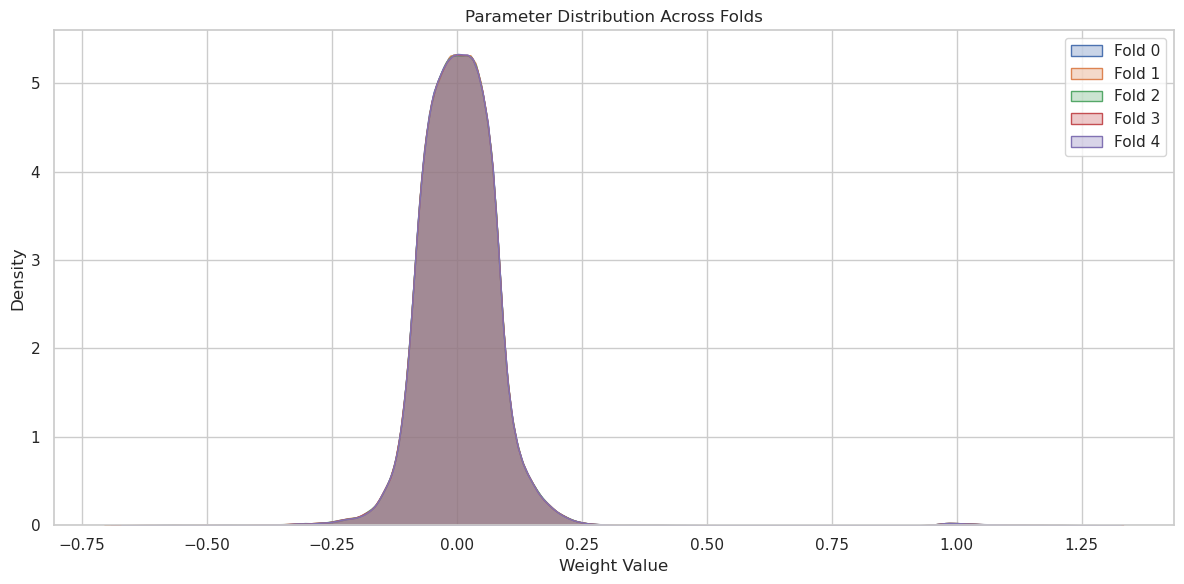

In [278]:
# Histogram showing variance of aggregated weights 
# Collect weights and plot kdes
all_weights = {f'Fold {i}': get_all_weights(model) for i, model in enumerate(models)}

plt.figure(figsize=(12, 6))
for fold, weights in all_weights.items():
    sns.kdeplot(weights, label=fold, fill=True, alpha=0.3)
plt.title('Parameter Distribution Across Folds')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.savefig("_images/parameter_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

Seems all parameters vary tightly. How about a breakdown of each parameter across all folds?

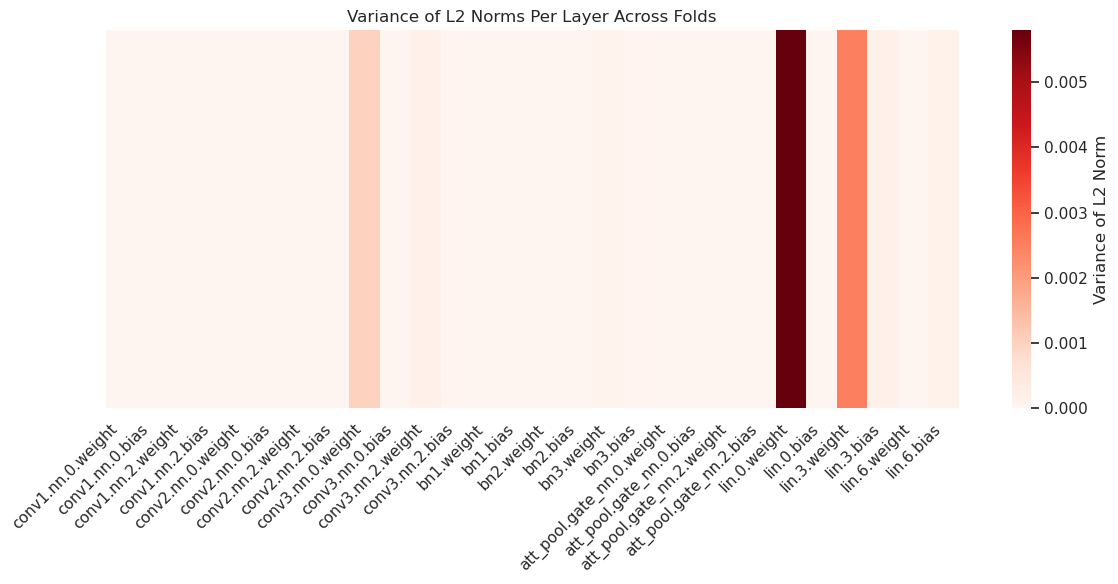

In [283]:
# Now let's have a look at each weight across all folds
# Collect norms for each model
norms_per_fold = {f'Fold {i}': get_weight_norms(model) for i, model in enumerate(models)}

df_norms = pd.DataFrame(norms_per_fold)

# Compute variance across folds per parameter
df_variance = df_norms.var(axis=1)

plt.figure(figsize=(12, 6))
sns.heatmap(df_variance.to_frame().T, cmap='Reds', cbar_kws={'label': 'Variance of L2 Norm'})
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.title('Variance of L2 Norms Per Layer Across Folds')
plt.tight_layout()
plt.savefig("_images/l2_norm_variance.png", dpi=300)
plt.show()

As we froze all but the last few layers, there is of course no variance overall or between folds.

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


<Figure size 1400x600 with 0 Axes>

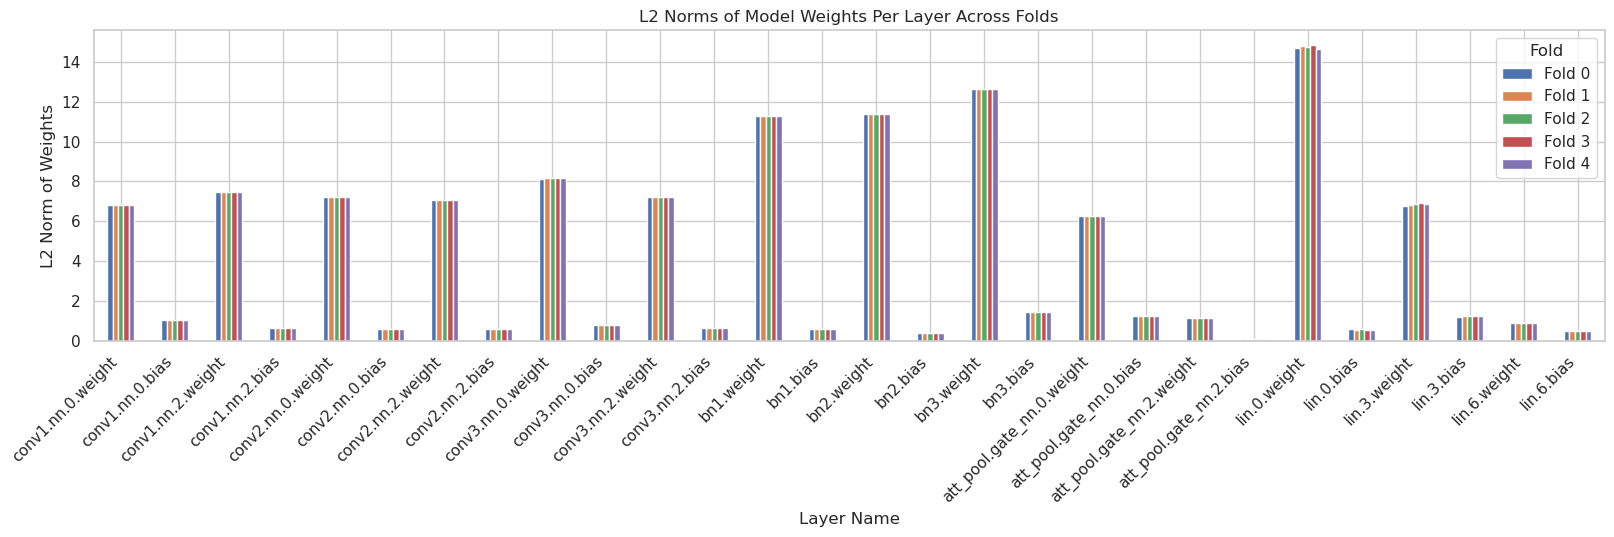

In [284]:
# Finally, let's look at the metrics per fold
num_folds = 5  
norms_per_fold = []

# TODO refactor so this isn't having to be loaded twice

for fold in range(num_folds):
    model = get_model()
    state_dict = torch.load(f'best_model_fold_{fold}.pth', map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    
    norms = get_weight_norms(model)
    norms_per_fold.append(norms)

df = pd.DataFrame(norms_per_fold)
df.index = [f'Fold {i}' for i in range(num_folds)]

plt.figure(figsize=(14, 6))
df.T.plot(kind='bar', figsize=(16, 6))
plt.title('L2 Norms of Model Weights Per Layer Across Folds')
plt.xlabel('Layer Name')
plt.ylabel('L2 Norm of Weights')
plt.grid(True)
plt.legend(title='Fold')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("_images/weight_norms_comparison.png", dpi=300)
plt.show()

That said, we've done our due diligence and certainly this model performs well enough, even without probing for real weaknesses, for our purposes.

In [285]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "hep_clint_gin.pt")